In [1]:
import pandas as pd
import numpy as np

# World Happiness Report 2023 — representative data
# Source: https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2023

df = pd.read_csv('../data/world_happiness_2023.csv')
df.columns = ['Country','Region','Happiness_Score','GDP','Social_Support',
              'Life_Expectancy','Freedom','Generosity','Corruption']


print(f"Dataset: {len(df)} countries, {len(df.columns)} columns")

Dataset: 63 countries, 9 columns


In [2]:
df.head()

,Country,Region,Happiness_Score,GDP,Social_Support,Life_Expectancy,Freedom,Generosity,Corruption
0,Finland,Western Europe,7.804,10.775,0.954,71.9,0.949,0.142,0.179
1,Denmark,Western Europe,7.586,10.933,0.954,72.7,0.931,0.168,0.234
2,Iceland,Western Europe,7.525,10.878,0.983,72.5,0.961,0.260,0.150
3,Israel,Middle East and North Africa,7.473,10.527,0.916,72.4,0.903,0.149,0.826
4,Netherlands,Western Europe,7.464,11.015,0.939,72.4,0.879,0.240,0.296


In [3]:

import plotly.express as px
import plotly.graph_objects as go

# Explore the dataset before you start
print("Regions in dataset:")
print(df['Region'].value_counts())
print("\nScore range:", df['Happiness_Score'].min(), "–", df['Happiness_Score'].max())
print("\nBottom 10 countries:")
print(df.nsmallest(10, 'Happiness_Score')[['Country','Region','Happiness_Score']])

Regions in dataset:
Region
Western Europe                  15
Latin America and Caribbean     13
Central and Eastern Europe       7
Sub-Saharan Africa               7
Middle East and North Africa     6
North America and ANZ            4
Southeast Asia                   4
South Asia                       4
East Asia                        3
Name: count, dtype: int64

Score range: 1.859 – 7.804

Bottom 10 countries:
        Country                        Region  Happiness_Score
60  Afghanistan                    South Asia            1.859
61      Lebanon  Middle East and North Africa            2.392
62     Zimbabwe            Sub-Saharan Africa            2.995
52     Ethiopia            Sub-Saharan Africa            3.564
53     Tanzania            Sub-Saharan Africa            3.698
48   Bangladesh                    South Asia            3.892
47        India                    South Asia            4.036
50        Kenya            Sub-Saharan Africa            4.112
54       Uganda

### Task 1 — Regional Comparison Bar Chart
What to build: A horizontal bar chart showing the average happiness score by region, sorted from highest to lowest.

#### Requirements:

Horizontal orientation (category names are long)
Sorted by score, descending (so the happiest region is at the top)
Zero baseline on x-axis
At least one design choice that goes beyond the Plotly default (colour, annotation, labels, etc.)
An insight title that answers: which region stands out and why does it matter?
Hint: Use df.groupby('Region')['Happiness_Score'].mean() to compute the averages.

In [4]:
# Task 1: Regional comparison bar chart
# -------------------------------------

# Step 1: Compute average happiness score by region
region_avg = (df.groupby('Region')['Happiness_Score']
              .mean()
              .reset_index()
              .sort_values('Happiness_Score'))  # sort for horizontal bar

print(region_avg)



                         Region  Happiness_Score
5                    South Asia         3.618250
7            Sub-Saharan Africa         4.064714
3  Middle East and North Africa         4.943333
6                Southeast Asia         5.695250
2   Latin America and Caribbean         5.699000
1                     East Asia         5.966000
0    Central and Eastern Europe         6.338143
4         North America and ANZ         7.018250
8                Western Europe         7.085533


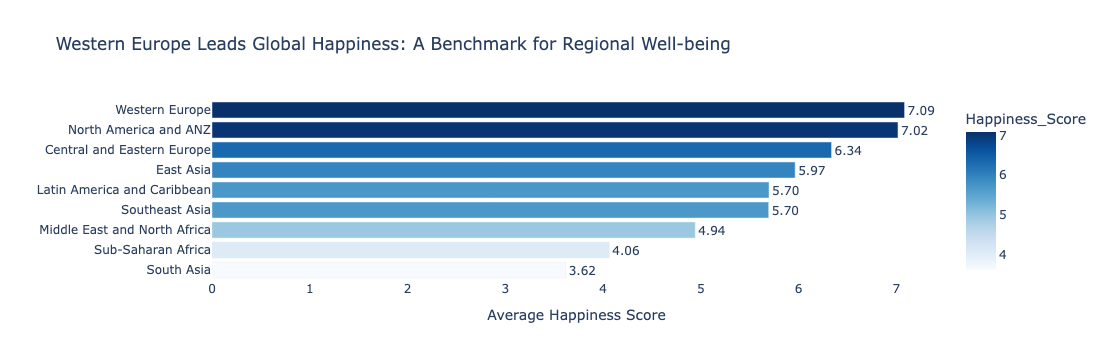

In [5]:
# Step 2: Build your chart
# Create the horizontal bar chart using your 'region_avg' dataframe
fig = px.bar(
    region_avg, 
    x='Happiness_Score',
    y='Region',
    orientation='h',  # Requirement: Horizontal orientation
    text='Happiness_Score', # Show the numbers on the bars
    color='Happiness_Score', # Requirement: Design choice (Color gradient)
    color_continuous_scale='Blues', # Design choice: Blue gradient
    
    # Requirement: Insight Title
    title="Western Europe Leads Global Happiness: A Benchmark for Regional Well-being" 
)

# Customize the layout
fig.update_layout(
    xaxis_title="Average Happiness Score",
    yaxis_title="", # Keep clean, region names are self-explanatory
    xaxis_rangemode="tozero", # Requirement: Zero baseline on x-axis
    plot_bgcolor='white', # Design choice: Clean white background
)

# Format the text labels on the bars to show 2 decimal places
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')

# Show the chart
fig.show()

### Task 2 — Bottom vs. Top: A Contrast Story
What to build: A bar chart that highlights the gap between the happiest and least happy countries, focusing on a specific insight.

#### Requirements:

Show the top 8 AND bottom 8 countries together (16 bars total)
Use colour to distinguish the two groups (not Plotly's default rainbow)
Add a visual separator or annotation that emphasises the gap
Insight title that tells the story of the gap
Hint: Use pd.concat([df.nlargest(8,'Happiness_Score'), df.nsmallest(8,'Happiness_Score')]) to get both groups.

Stretch goal: Add a vertical reference line showing the global average.

In [6]:
# Task 2: Top 8 vs. Bottom 8 contrast
# ------------------------------------

# Step 1: Get top and bottom countries
top8 = df.nlargest(8, 'Happiness_Score').copy()
top8['Group'] = 'Top 8'
bottom8 = df.nsmallest(8, 'Happiness_Score').copy()
bottom8['Group'] = 'Bottom 8'

combined = pd.concat([bottom8, top8]).sort_values('Happiness_Score')
global_avg = df['Happiness_Score'].mean()
print(f"Global average: {global_avg:.2f}")

Global average: 5.81


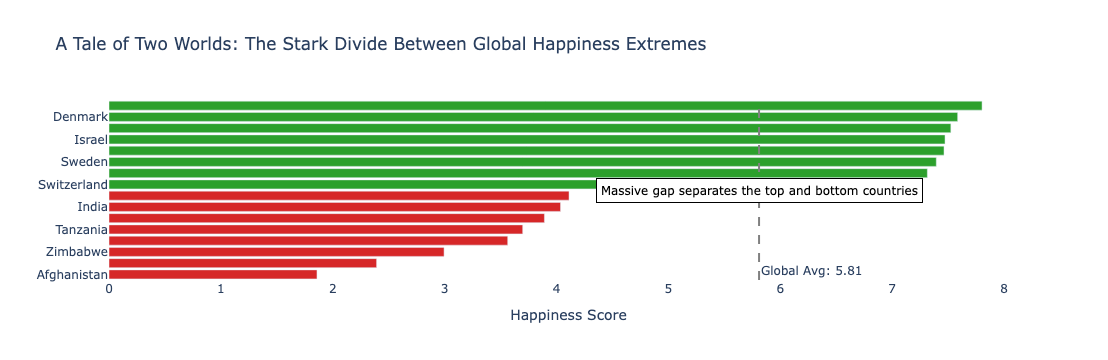

In [8]:
# Step 2: Build your chart

# Note: If your country column is just called 'Country', change 'Country name' below.
fig = px.bar(
    combined,
    x='Happiness_Score',
    y='Country', 
    color='Group',      # Colors the bars based on 'Top 8' vs 'Bottom 8'
    orientation='h',
    
    # Requirement: Custom colors to distinguish groups (Green for Top, Red for Bottom)
    color_discrete_map={'Top 8': '#2CA02C', 'Bottom 8': '#D62728'}, 
    
    # Requirement: Insight Title telling the story of the gap
    title="A Tale of Two Worlds: The Stark Divide Between Global Happiness Extremes"
)

# STRETCH GOAL: Add a vertical reference line for the global average
fig.add_vline(
    x=global_avg, 
    line_width=2, 
    line_dash="dash", 
    line_color="gray",
    annotation_text=f"Global Avg: {global_avg:.2f}", 
    annotation_position="bottom right"
)

# Requirement: Add an annotation to emphasize the gap
# Because there are 16 bars, the space between the top 8 and bottom 8 sits at y=7.5
fig.add_annotation(
    x=global_avg,          # Centers the box on the average line
    y=7.5,                 # Places the box right in the empty gap between the groups
    text="Massive gap separates the top and bottom countries",
    showarrow=False,
    font=dict(size=12, color="black"),
    bgcolor="white",
    bordercolor="black",
    borderwidth=1,
    borderpad=4
)

# Clean up the layout
fig.update_layout(
    xaxis_title="Happiness Score",
    yaxis_title="", # Keep y-axis clean
    plot_bgcolor='white',
    showlegend=False, # We don't need a legend because the colors/groups are obvious
    xaxis_rangemode="tozero" # Keep zero baseline
)

fig.show()


#### Done? Stretch Goal
If you finish both tasks with time to spare, try this:

##### Task 3 (stretch): Build a grouped bar chart comparing 2 sub-factors (e.g. GDP_per_capita and Freedom) across the 5 most populated regions. Use colour meaningfully and write an insight title.

Regions to include: 'Western Europe', 'Latin America', 'East Asia', 'Sub-Saharan Africa', 'South Asia'

In [9]:
# 1. Make sure you are in your repo folder
%cd data_Visualization_Siddhant_41724324

# 2. Pull the newest class material from the professor
!git pull upstream main

# 3. Add your specific exercise folder
!git add Week02_ex/

# 4. Commit your work
!git commit -m "Lecture 02 exercise"

# 5. Push everything to your GitHub
!git push origin main

[Errno 2] No such file or directory: 'data_Visualization_Siddhant_41724324'
/Users/siddhantmathapati/Downloads/data_Visualization_Siddhant_41724324/Week02_ex
From https://github.com/dina-deifallah/data-viz-class-material-w2026
 * branch            main       -> FETCH_HEAD
Already up to date.
fatal: pathspec 'Week02_ex/' did not match any files
On branch main
Your branch is ahead of 'origin/main' by 5 commits.
  (use "git push" to publish your local commits)

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	./
	../week01_exercise/

nothing added to commit but untracked files present (use "git add" to track)
Everything up-to-date
